# MVP — Machine Learning & Analytics

**Nome:** Camila de Cássia Lourenço dos Santos  
**Matrícula:** 4052025001771  
**Data:** 05/07/2026  

**Dataset:** E-commerce Orders Dataset 2026 | SCRA  
**Fonte:** https://www.kaggle.com/datasets/mmumairkhattak/e-commerce-orders-dataset-2026-scra  

**Tipo de problema:** Clusterização

Escolhi trabalhar com segmentação de clientes porque esse tipo de análise é bastante comum em empresas de e-commerce. A ideia é entender que nem todos os clientes se comportam da mesma forma: alguns compram com frequência, outros gastam mais, alguns compraram recentemente e outros parecem estar mais distantes. Com isso, a empresa pode pensar em estratégias diferentes para cada perfil.

## Objetivo

Identificar grupos de clientes com perfis semelhantes usando clusterização K-Means a partir de variáveis como:

- quantidade de pedidos;
- valor total gasto;
- ticket médio;
- o quão recente é a última compra;
- diversidade de categorias compradas.

## Tipo de problema

Este é um problema de aprendizado não supervisionado, pois não temos uma variável-alvo pronta. O objetivo é descobrir padrões nos dados.

## Hipóteses iniciais da análise

**Hipótese 1:** Clientes com maior quantidade média de pedidos tendem a ter maior valor total gasto.  
**Hipótese 2:** Clientes com maior valor total médio podem representar um perfil de maior valor para o negócio.  
**Hipótese 3:** Clientes com maior ticket médio podem indicar um grupo com compras de maior valor.  
**Hipótese 4:** Clientes com menor recência, ou seja, que compraram há menos tempo, podem indicar maior engajamento.


## 1. Instalação e importação das bibliotecas

Nesta primeira parte, importei as bibliotecas que serão usadas no trabalho.

In [1]:
# A biblioteca kagglehub ajuda a baixar o dataset do Kaggle.
# As demais bibliotecas serão usadas para análise, gráficos e clusterização.

!pip -q install kagglehub openpyxl

import os
import glob
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid')


## 2. Carregamento dos dados

O código abaixo baixa o dataset diretamente do Kaggle usando `kagglehub`.

In [2]:
# Baixando o dataset diretamente do Kaggle

dataset_path = kagglehub.dataset_download(
    'mmumairkhattak/e-commerce-orders-dataset-2026-scra'
)

print('Dataset baixado em:', dataset_path)

# Procurando o arquivo CSV dentro da pasta baixada
csv_files = glob.glob(os.path.join(dataset_path, '*.csv'))

# Selecionando o arquivo principal do dataset
csv_path = [
    f for f in csv_files
    if os.path.basename(f).lower() == 'ecommerce_orders_dataset.csv'
][0]

# Leitura do dataset
df = pd.read_csv(csv_path)

print('Arquivo utilizado:', csv_path)
print('Dimensão da base:', df.shape)

df.head()


100%|██████████| 1.71M/1.71M [00:00<00:00, 93.7MB/s]

Extracting files...
Dataset baixado em: /root/.cache/kagglehub/datasets/mmumairkhattak/e-commerce-orders-dataset-2026-scra/versions/1


Arquivo utilizado: /root/.cache/kagglehub/datasets/mmumairkhattak/e-commerce-orders-dataset-2026-scra/versions/1/ecommerce_orders_dataset.csv
Dimensão da base: (30000, 41)


,Order_ID,Customer_ID,Order_Date,Year,Month,Day,Day_Of_Week,Quarter,Customer_Age,Customer_Gender,Country,City,Customer_Segment,Product_ID,Product_Category,Product_Subcategory,Brand,Unit_Price,Quantity,Discount_Percent,Discount_Amount,Coupon_Used,Shipping_Cost,Tax_Amount,Order_Amount,Payment_Method,Device_Type,Traffic_Source,Membership_Status,Shipping_Method,Warehouse_Region,Delivery_Days,Order_Status,Returned,Review_Rating,Customer_Lifetime_Value,Profit_Margin_Percent,Profit_Amount,Season,Holiday_Season,High_Value_Order
0,615717,CUST007322,2023-01-01,2023,1,1,Sunday,1,32,Male,Germany,Dubai,Loyal,PROD02374,Books,Comics,PrimePlus,18.44,3,10,5.53,Yes,15.50,2.91,68.20,Debit Card,Mobile,Social Media,Standard,Express,North,2,Delivered,No,4.4,2144.92,23.10,15.75,Winter,No,No
1,626919,CUST004717,2023-01-01,2023,1,1,Sunday,1,50,Male,France,London,Returning,PROD01378,Sports,Equipment,PrimePlus,46.58,1,40,18.63,Yes,5.87,4.91,38.73,Wallet,Mobile,Email,Standard,Standard,East,9,Delivered,No,4.1,817.17,8.57,3.32,Winter,No,No
2,615781,CUST004415,2023-01-01,2023,1,1,Sunday,1,61,Male,India,Berlin,Returning,PROD01850,Beauty,Skincare,Zenith,62.18,3,35,65.29,Yes,15.91,16.50,153.66,Cash on Delivery,Mobile,Paid Ads,Standard,Express,Central,2,Delivered,No,5.0,541.16,29.72,45.67,Winter,No,No
3,621747,CUST004114,2023-01-01,2023,1,1,Sunday,1,34,Male,United States,Riyadh,Returning,PROD00545,Fashion,Women Clothing,FreshMart,91.06,3,0,0.00,No,9.17,16.02,298.37,Wallet,Desktop,Organic Search,Standard,Standard,South,6,Returned,Yes,3.4,700.49,25.22,75.25,Winter,No,No
4,625881,CUST000145,2023-01-01,2023,1,1,Sunday,1,37,Male,India,Mumbai,Premium,PROD01398,Beauty,Makeup,Zenith,99.44,1,15,14.92,Yes,13.63,7.60,105.75,PayPal,Mobile,Referral,Standard,Express,Central,8,Delivered,No,3.6,2133.77,24.64,26.06,Winter,No,No


## 3. Entendimento inicial da base

Nesta etapa, verifico a estrutura da base, os tipos de dados, os valores ausentes e possíveis duplicidades.

In [3]:
display(df.head())

# Resumo das colunas
resumo_colunas = pd.DataFrame({
    'coluna': df.columns,
    'tipo': df.dtypes.astype(str),
    'nulos': df.isna().sum().values,
    'perc_nulos': (df.isna().mean().values * 100).round(2),
    'qtd_unicos': df.nunique().values
})

display(resumo_colunas)

print('Quantidade de linhas duplicadas:', df.duplicated().sum())


,Order_ID,Customer_ID,Order_Date,Year,Month,Day,Day_Of_Week,Quarter,Customer_Age,Customer_Gender,Country,City,Customer_Segment,Product_ID,Product_Category,Product_Subcategory,Brand,Unit_Price,Quantity,Discount_Percent,Discount_Amount,Coupon_Used,Shipping_Cost,Tax_Amount,Order_Amount,Payment_Method,Device_Type,Traffic_Source,Membership_Status,Shipping_Method,Warehouse_Region,Delivery_Days,Order_Status,Returned,Review_Rating,Customer_Lifetime_Value,Profit_Margin_Percent,Profit_Amount,Season,Holiday_Season,High_Value_Order
0,615717,CUST007322,2023-01-01,2023,1,1,Sunday,1,32,Male,Germany,Dubai,Loyal,PROD02374,Books,Comics,PrimePlus,18.44,3,10,5.53,Yes,15.50,2.91,68.20,Debit Card,Mobile,Social Media,Standard,Express,North,2,Delivered,No,4.4,2144.92,23.10,15.75,Winter,No,No
1,626919,CUST004717,2023-01-01,2023,1,1,Sunday,1,50,Male,France,London,Returning,PROD01378,Sports,Equipment,PrimePlus,46.58,1,40,18.63,Yes,5.87,4.91,38.73,Wallet,Mobile,Email,Standard,Standard,East,9,Delivered,No,4.1,817.17,8.57,3.32,Winter,No,No
2,615781,CUST004415,2023-01-01,2023,1,1,Sunday,1,61,Male,India,Berlin,Returning,PROD01850,Beauty,Skincare,Zenith,62.18,3,35,65.29,Yes,15.91,16.50,153.66,Cash on Delivery,Mobile,Paid Ads,Standard,Express,Central,2,Delivered,No,5.0,541.16,29.72,45.67,Winter,No,No
3,621747,CUST004114,2023-01-01,2023,1,1,Sunday,1,34,Male,United States,Riyadh,Returning,PROD00545,Fashion,Women Clothing,FreshMart,91.06,3,0,0.00,No,9.17,16.02,298.37,Wallet,Desktop,Organic Search,Standard,Standard,South,6,Returned,Yes,3.4,700.49,25.22,75.25,Winter,No,No
4,625881,CUST000145,2023-01-01,2023,1,1,Sunday,1,37,Male,India,Mumbai,Premium,PROD01398,Beauty,Makeup,Zenith,99.44,1,15,14.92,Yes,13.63,7.60,105.75,PayPal,Mobile,Referral,Standard,Express,Central,8,Delivered,No,3.6,2133.77,24.64,26.06,Winter,No,No


,coluna,tipo,nulos,perc_nulos,qtd_unicos
Order_ID,Order_ID,int64,0,0.0,30000
Customer_ID,Customer_ID,object,0,0.0,8683
Order_Date,Order_Date,object,0,0.0,1461
Year,Year,int64,0,0.0,4
Month,Month,int64,0,0.0,12
Day,Day,int64,0,0.0,31
Day_Of_Week,Day_Of_Week,object,0,0.0,7
Quarter,Quarter,int64,0,0.0,4
Customer_Age,Customer_Age,int64,0,0.0,58
Customer_Gender,Customer_Gender,object,0,0.0,3


Quantidade de linhas duplicadas: 0


A base inicial possui 30.000 registros de pedidos e 8.683 clientes únicos, sem valores nulos nas colunas analisadas. Também é possível observar uma boa variedade de informações, como dados do cliente, produto, pagamento, entrega, valor do pedido e comportamento de compra. Isso indica que a base está bem estruturada e adequada para criar indicadores para seguir com o trabalho.

## Limitações do dataset

Apesar de a base estar completa e sem valores nulos, uma limitação é que os dados representam apenas o histórico disponível no dataset. A análise também não considera fatores externos, como campanhas de marketing, mudanças de preço ou comportamento futuro dos clientes.

## 4. Padronização dos nomes das colunas

Para deixar a base mais fácil de trabalhar, padronizei os nomes das colunas para minúsculas, sem espaços e sem caracteres especiais.

In [4]:
import re
import unicodedata

def normalizar_coluna(col):
    col = str(col).strip().lower()
    col = unicodedata.normalize('NFKD', col).encode('ascii', errors='ignore').decode('utf-8')
    col = re.sub(r'[^a-z0-9]+', '_', col)
    col = re.sub(r'_+', '_', col).strip('_')
    return col

df.columns = [normalizar_coluna(c) for c in df.columns]

print(df.columns.tolist())


['order_id', 'customer_id', 'order_date', 'year', 'month', 'day', 'day_of_week', 'quarter', 'customer_age', 'customer_gender', 'country', 'city', 'customer_segment', 'product_id', 'product_category', 'product_subcategory', 'brand', 'unit_price', 'quantity', 'discount_percent', 'discount_amount', 'coupon_used', 'shipping_cost', 'tax_amount', 'order_amount', 'payment_method', 'device_type', 'traffic_source', 'membership_status', 'shipping_method', 'warehouse_region', 'delivery_days', 'order_status', 'returned', 'review_rating', 'customer_lifetime_value', 'profit_margin_percent', 'profit_amount', 'season', 'holiday_season', 'high_value_order']


## 5. Identificação das principais colunas

Aqui defini as colunas que serão usadas na análise, indicando quais campos representam cliente, pedido, data, valor, quantidade e categoria.

In [5]:
col_cliente = 'customer_id'
col_pedido = 'order_id'
col_data = 'order_date'
col_valor = 'order_amount'
col_qtd = 'quantity'
col_categoria = 'product_category'

colunas_usadas = [
    col_cliente,
    col_pedido,
    col_data,
    col_valor,
    col_qtd,
    col_categoria
]

# Conferindo as colunas selecionadas
df[colunas_usadas].head()


,customer_id,order_id,order_date,order_amount,quantity,product_category
0,CUST007322,615717,2023-01-01,68.20,3,Books
1,CUST004717,626919,2023-01-01,38.73,1,Sports
2,CUST004415,615781,2023-01-01,153.66,3,Beauty
3,CUST004114,621747,2023-01-01,298.37,3,Fashion
4,CUST000145,625881,2023-01-01,105.75,1,Beauty


## 6. Tratamento dos dados

Nesta etapa, criei uma cópia da base original e fiz alguns tratamentos básicos. Removi duplicidades, converti valores e datas, e mantive apenas registros com cliente e valor de compra válidos.

In [6]:
df_tratado = df.copy()

# Removendo possíveis duplicidades
df_tratado = df_tratado.drop_duplicates()

# Convertendo o valor do pedido para formato numérico
df_tratado[col_valor] = pd.to_numeric(df_tratado[col_valor], errors='coerce')

# Convertendo quantidade para numérico
df_tratado[col_qtd] = pd.to_numeric(df_tratado[col_qtd], errors='coerce')

# Convertendo a data do pedido
df_tratado[col_data] = pd.to_datetime(df_tratado[col_data], errors='coerce')

# Mantendo apenas registros válidos para a análise
df_tratado = df_tratado.dropna(subset=[col_cliente, col_valor, col_data])
df_tratado = df_tratado[df_tratado[col_valor] > 0]

print('Dimensão após tratamento:', df_tratado.shape)

df_tratado.head()


Dimensão após tratamento: (30000, 41)


,order_id,customer_id,order_date,year,month,day,day_of_week,quarter,customer_age,customer_gender,country,city,customer_segment,product_id,product_category,product_subcategory,brand,unit_price,quantity,discount_percent,discount_amount,coupon_used,shipping_cost,tax_amount,order_amount,payment_method,device_type,traffic_source,membership_status,shipping_method,warehouse_region,delivery_days,order_status,returned,review_rating,customer_lifetime_value,profit_margin_percent,profit_amount,season,holiday_season,high_value_order
0,615717,CUST007322,2023-01-01,2023,1,1,Sunday,1,32,Male,Germany,Dubai,Loyal,PROD02374,Books,Comics,PrimePlus,18.44,3,10,5.53,Yes,15.50,2.91,68.20,Debit Card,Mobile,Social Media,Standard,Express,North,2,Delivered,No,4.4,2144.92,23.10,15.75,Winter,No,No
1,626919,CUST004717,2023-01-01,2023,1,1,Sunday,1,50,Male,France,London,Returning,PROD01378,Sports,Equipment,PrimePlus,46.58,1,40,18.63,Yes,5.87,4.91,38.73,Wallet,Mobile,Email,Standard,Standard,East,9,Delivered,No,4.1,817.17,8.57,3.32,Winter,No,No
2,615781,CUST004415,2023-01-01,2023,1,1,Sunday,1,61,Male,India,Berlin,Returning,PROD01850,Beauty,Skincare,Zenith,62.18,3,35,65.29,Yes,15.91,16.50,153.66,Cash on Delivery,Mobile,Paid Ads,Standard,Express,Central,2,Delivered,No,5.0,541.16,29.72,45.67,Winter,No,No
3,621747,CUST004114,2023-01-01,2023,1,1,Sunday,1,34,Male,United States,Riyadh,Returning,PROD00545,Fashion,Women Clothing,FreshMart,91.06,3,0,0.00,No,9.17,16.02,298.37,Wallet,Desktop,Organic Search,Standard,Standard,South,6,Returned,Yes,3.4,700.49,25.22,75.25,Winter,No,No
4,625881,CUST000145,2023-01-01,2023,1,1,Sunday,1,37,Male,India,Mumbai,Premium,PROD01398,Beauty,Makeup,Zenith,99.44,1,15,14.92,Yes,13.63,7.60,105.75,PayPal,Mobile,Referral,Standard,Express,Central,8,Delivered,No,3.6,2133.77,24.64,26.06,Winter,No,No


## 7. Análise Exploratória dos Dados — EDA

A análise exploratória ajudará a entender o comportamento geral da base. Nesta parte, calcularei alguns indicadores gerais e observarei gráficos simples sobre vendas e categorias.

In [7]:
qtd_clientes = df_tratado[col_cliente].nunique()
qtd_pedidos = df_tratado[col_pedido].nunique()
valor_total = df_tratado[col_valor].sum()
ticket_medio = df_tratado[col_valor].mean()

resumo = pd.DataFrame({
    'Indicador': ['Clientes únicos', 'Pedidos/Registros', 'Valor total', 'Ticket médio'],
    'Valor': [qtd_clientes, qtd_pedidos, round(valor_total, 2), round(ticket_medio, 2)]
})

display(resumo)


,Indicador,Valor
0,Clientes únicos,8683.00
1,Pedidos/Registros,30000.00
2,Valor total,11370043.99
3,Ticket médio,379.00


Observei que a base possui um bom volume de clientes e pedidos para uma análise de segmentação. Esses indicadores iniciais ajudam a ter uma visão geral antes de criar os grupos de clientes.

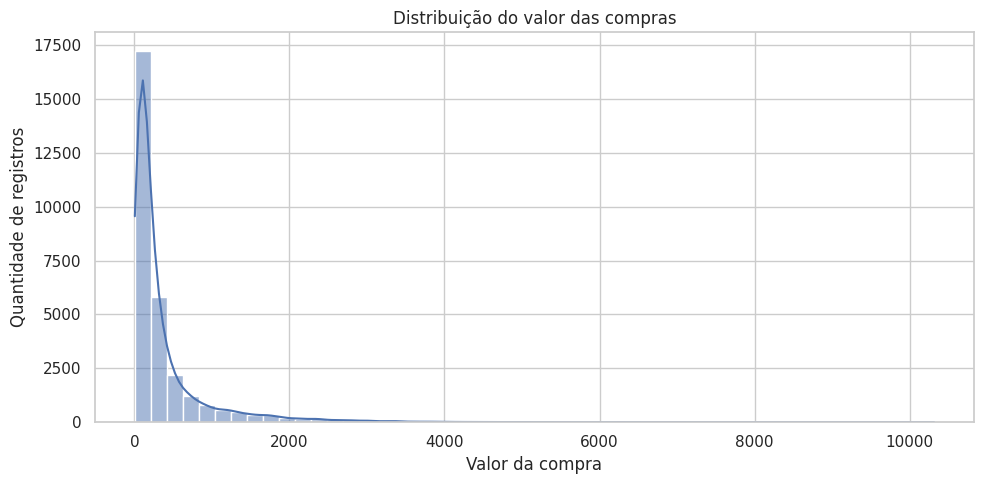

In [8]:
plt.figure(figsize=(10, 5))

sns.histplot(df_tratado[col_valor], bins=50, kde=True)

plt.title('Distribuição do valor das compras')
plt.xlabel('Valor da compra')
plt.ylabel('Quantidade de registros')

plt.tight_layout()
plt.show()


A distribuição acima mostra que a maior parte dos pedidos possui valores mais baixos. Também existem poucos pedidos com valores mais altos, formando uma cauda à direita. Esses pedidos fora do padrão podem influenciar a análise dos clientes.

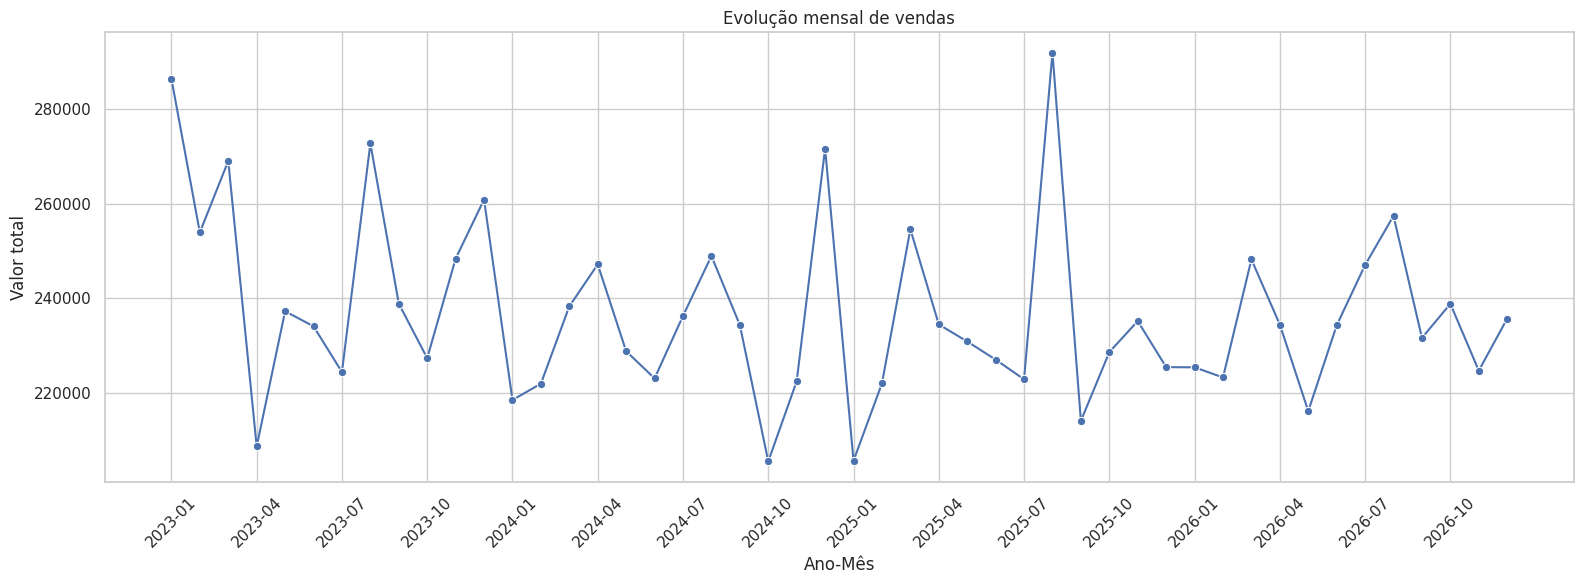

In [9]:
vendas_tempo = (
    df_tratado
    .assign(ano_mes=df_tratado[col_data].dt.to_period('M').astype(str))
    .groupby('ano_mes', as_index=False)[col_valor]
    .sum()
)

plt.figure(figsize=(16, 6))

sns.lineplot(
    data=vendas_tempo,
    x='ano_mes',
    y=col_valor,
    marker='o'
)

plt.title('Evolução mensal de vendas')
plt.xlabel('Ano-Mês')
plt.ylabel('Valor total')

# Mostra alguns meses no eixo X para o gráfico ficar mais legível
plt.xticks(
    ticks=range(0, len(vendas_tempo), 3),
    labels=vendas_tempo['ano_mes'][::3],
    rotation=45
)

plt.tight_layout()
plt.show()


O gráfico acima mostra que as vendas mensais variam ao longo do período, sem uma tendência única de crescimento ou queda. Essa oscilação pode estar relacionada a sazonalidade, campanhas ou períodos específicos de maior consumo.

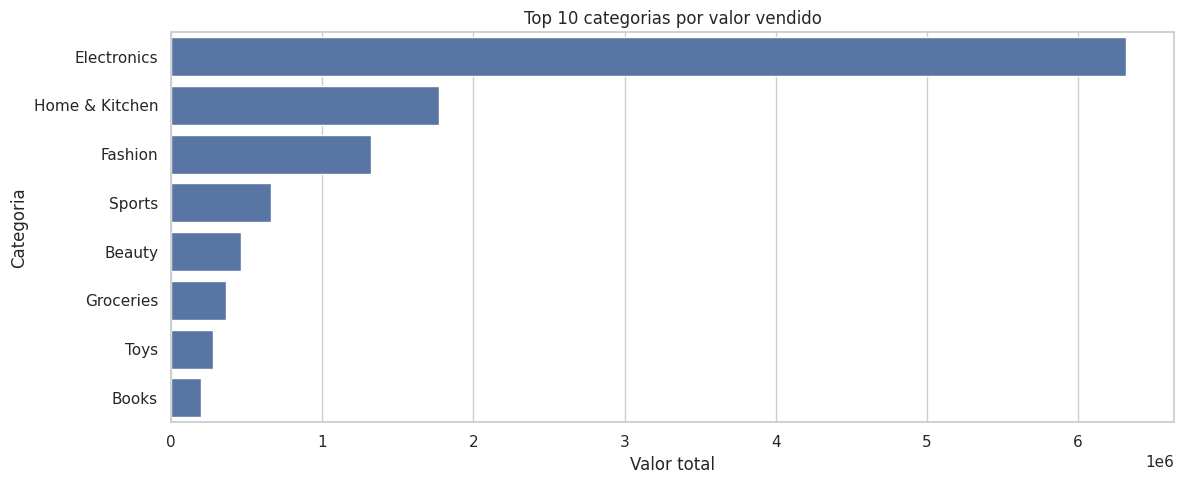

In [10]:
top_categorias = (
    df_tratado
    .groupby(col_categoria, as_index=False)[col_valor]
    .sum()
    .sort_values(col_valor, ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 5))

sns.barplot(data=top_categorias, x=col_valor, y=col_categoria)

plt.title('Top 10 categorias por valor vendido')
plt.xlabel('Valor total')
plt.ylabel('Categoria')

plt.tight_layout()
plt.show()


O gráfico acima mostra quais categorias concentram maior valor vendido, ajudando a entender quais tipos de produto têm maior peso na receita da base analisada.

## 8. Criação da base analítica por cliente

Para segmentar clientes, transformei a base de pedidos em uma base no nível do cliente. Assim, cada linha passa a representar um cliente, com indicadores do seu comportamento de compra.

In [11]:
# Consolidando os pedidos por cliente

cliente_agg = (
    df_tratado
    .groupby(col_cliente)
    .agg(
        qtd_pedidos=(col_pedido, 'nunique'),
        valor_total=(col_valor, 'sum'),
        ticket_medio=(col_valor, 'mean'),
        ultima_compra=(col_data, 'max'),
        qtd_categorias=(col_categoria, 'nunique')
    )
    .reset_index()
)

# Calculando a recência, ou seja, há quantos dias o cliente fez a última compra
data_referencia = cliente_agg['ultima_compra'].max() + pd.Timedelta(days=1)
cliente_agg['recencia_dias'] = (data_referencia - cliente_agg['ultima_compra']).dt.days

# Arredondando valores para facilitar a leitura
cliente_agg['valor_total'] = cliente_agg['valor_total'].round(2)
cliente_agg['ticket_medio'] = cliente_agg['ticket_medio'].round(2)

print('Base analítica por cliente:', cliente_agg.shape)

display(cliente_agg.head())


Base analítica por cliente: (8683, 7)


,customer_id,qtd_pedidos,valor_total,ticket_medio,ultima_compra,qtd_categorias,recencia_dias
0,CUST000001,2,575.87,287.94,2025-06-24,2,556
1,CUST000002,6,4353.10,725.52,2025-11-23,5,404
2,CUST000003,4,637.60,159.40,2026-12-30,4,2
3,CUST000004,2,388.31,194.16,2023-12-12,1,1116
4,CUST000005,6,2439.93,406.66,2026-09-06,5,117


## 9. Seleção das variáveis para clusterização

Selecionei variáveis para facilitar a interpretação dos grupos de clientes. Depois, padronizei os dados, pois o K-Means é influenciado pela escala das variáveis.

In [12]:
features = [
    'qtd_pedidos',
    'valor_total',
    'ticket_medio',
    'recencia_dias',
    'qtd_categorias'
]

X = cliente_agg[features].copy()
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pd.DataFrame(X_scaled, columns=features).head()


,qtd_pedidos,valor_total,ticket_medio,recencia_dias,qtd_categorias
0,-0.835008,-0.583062,-0.238619,0.509133,-0.625947
1,1.460504,2.419102,0.904590,0.051358,1.858859
2,0.312748,-0.533998,-0.574439,-1.159338,1.030590
3,-0.835008,-0.732135,-0.483626,2.195675,-1.454216
4,1.460504,0.898504,0.071546,-0.812995,1.858859


## Modelo escolhido

O K-Means foi escolhido por ser uma técnica bastante usada em problemas de segmentação e fácil de interpretar. Como este trabalho é um MVP, o foco foi criar uma primeira versão da segmentação e comparar diferentes valores de k.

Como o problema é de clusterização, não foi feita uma divisão tradicional entre treino e teste. A avaliação foi planejada com métricas próprias para agrupamento, como inércia e Silhouette Score.

## 10. Escolha do número de clusters

Nesta etapa, testei diferentes valores de k para escolher a melhor quantidade de grupos.

Usei o Método do Cotovelo para avaliar a compactação dos clusters e o Silhouette Score para verificar se os grupos ficaram bem separados.

,k,inercia,silhouette
0,2,28955.785910,0.320810
1,3,22679.338999,0.318556
2,4,18319.269358,0.293153
3,5,15777.344465,0.274708
4,6,13988.198436,0.280513
5,7,12522.131819,0.278110
6,8,11538.650523,0.273660


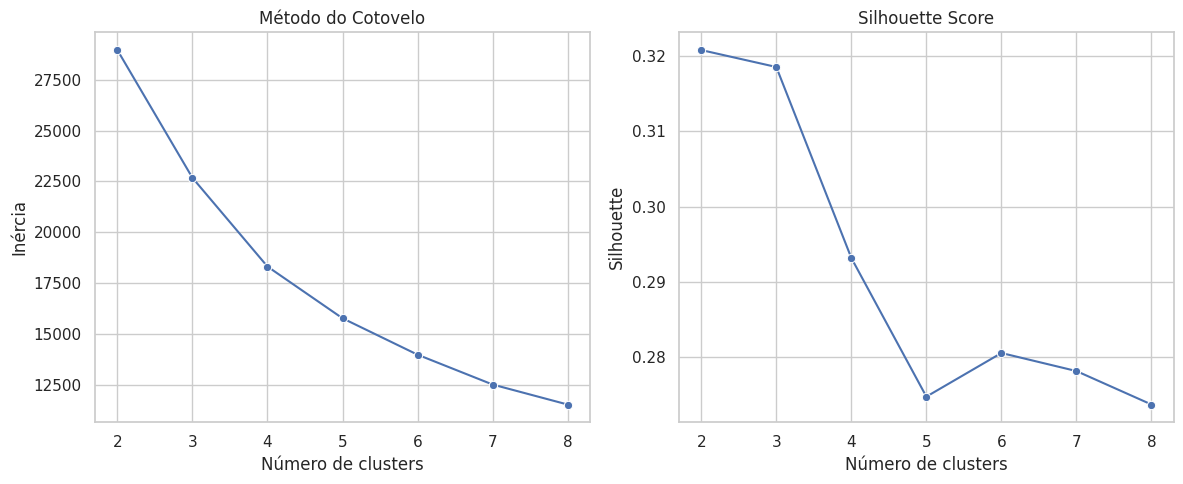

In [13]:
k_values = range(2, 9)

inertias = []
silhouettes = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(X_scaled)

    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_scaled, clusters))

metricas_k = pd.DataFrame({
    'k': list(k_values),
    'inercia': inertias,
    'silhouette': silhouettes
})

display(metricas_k)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.lineplot(data=metricas_k, x='k', y='inercia', marker='o')
plt.title('Método do Cotovelo')
plt.xlabel('Número de clusters')
plt.ylabel('Inércia')

plt.subplot(1, 2, 2)
sns.lineplot(data=metricas_k, x='k', y='silhouette', marker='o')
plt.title('Silhouette Score')
plt.xlabel('Número de clusters')
plt.ylabel('Silhouette')

plt.tight_layout()
plt.show()


Pela análise dos gráficos, escolhi k = 2. Esse valor, visualmente falando, apresentou o melhor resultado de Silhouette Score e manteve a segmentação mais fácil de interpretar.

## 11. Treinamento do modelo K-Means

Nesta etapa, treinei o modelo K-Means e cada cliente recebeu um cluster de acordo com seu perfil de compra.

In [14]:
melhor_k = 2

print('Número de clusters escolhido:', melhor_k)

kmeans = KMeans(n_clusters=melhor_k, random_state=42, n_init=10)

cliente_agg['cluster'] = kmeans.fit_predict(X_scaled)

cliente_agg.head()


Número de clusters escolhido: 2


,customer_id,qtd_pedidos,valor_total,ticket_medio,ultima_compra,qtd_categorias,recencia_dias,cluster
0,CUST000001,2,575.87,287.94,2025-06-24,2,556,1
1,CUST000002,6,4353.10,725.52,2025-11-23,5,404,0
2,CUST000003,4,637.60,159.40,2026-12-30,4,2,0
3,CUST000004,2,388.31,194.16,2023-12-12,1,1116,1
4,CUST000005,6,2439.93,406.66,2026-09-06,5,117,0


## 12. Perfil dos clusters

Nesta etapa, analisei as principais características de cada grupo de clientes. O objetivo foi entender a quantidade de clientes em cada cluster, o valor médio gasto, o ticket médio, a quantidade média de pedidos e a recência das compras.

In [15]:
perfil_clusters = (
    cliente_agg
    .groupby('cluster')
    .agg(
        qtd_clientes=(col_cliente, 'count'),
        qtd_pedidos_media=('qtd_pedidos', 'mean'),
        valor_total_medio=('valor_total', 'mean'),
        ticket_medio_medio=('ticket_medio', 'mean'),
        recencia_media=('recencia_dias', 'mean'),
        qtd_categorias_media=('qtd_categorias', 'mean')
    )
    .reset_index()
)

perfil_clusters['perc_clientes'] = (
    perfil_clusters['qtd_clientes'] / perfil_clusters['qtd_clientes'].sum() * 100
).round(2)

colunas_media = [
    'qtd_pedidos_media',
    'valor_total_medio',
    'ticket_medio_medio',
    'recencia_media',
    'qtd_categorias_media'
]

perfil_clusters[colunas_media] = perfil_clusters[colunas_media].round(2)

display(perfil_clusters.sort_values('valor_total_medio', ascending=False))


,cluster,qtd_clientes,qtd_pedidos_media,valor_total_medio,ticket_medio_medio,recencia_media,qtd_categorias_media,perc_clientes
0,0,3781,4.90,2188.98,497.89,227.78,3.73,43.54
1,1,4902,2.34,631.07,287.79,509.72,2.00,56.46


O cluster 0 reúne clientes com maior valor total médio, maior ticket médio e maior quantidade média de pedidos. Já o cluster 1 concentra mais clientes, mas apresenta menor valor médio gasto, menor frequência de pedidos e maior recência. Isso indica que o cluster 0 representa clientes mais valiosos e ativos, enquanto o cluster 1 reúne clientes com menor engajamento de compra.

## 12.1 Análise das hipóteses iniciais com base nos clusters

Após criar os clusters, comparei abaixo, de forma visual, os principais indicadores de cada grupo.

**Hipótese 1:** clientes com mais pedidos tendem a gastar mais.  
Essa hipótese parece válida, pois o cluster 0 teve maior média de pedidos e maior valor total médio.

**Hipótese 2:** clientes com maior valor total médio representam maior valor para o negócio.  
Essa hipótese parece válida, pois o cluster 0 apresentou maior valor total médio.

**Hipótese 3:** clientes com maior ticket médio indicam compras de maior valor.  
Essa hipótese também parece válida, já que o cluster 0 apresentou maior ticket médio.

**Hipótese 4:** clientes que compraram há menos tempo indicam maior engajamento.  
O cluster 0 teve menor recência, mostrando clientes com compras mais recentes.

De forma geral, o cluster 0 representa clientes mais ativos e de maior valor, enquanto o cluster 1 reúne clientes com menor engajamento recente.


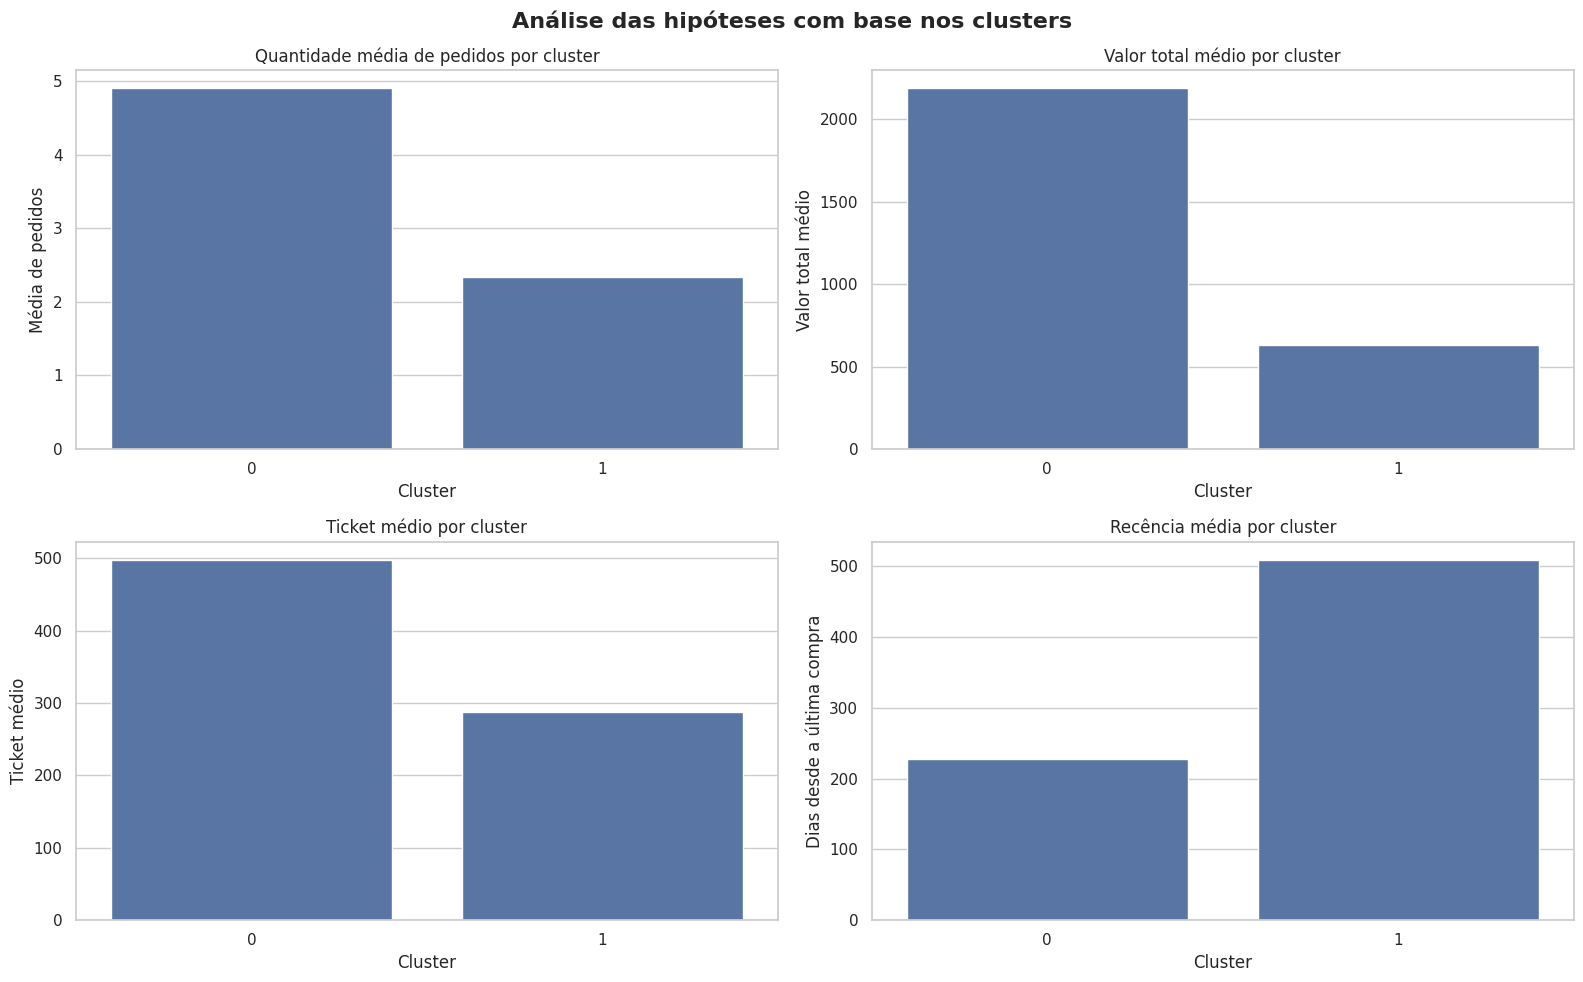

In [16]:
fig, ax = plt.subplots(2, 2, figsize=(16, 10))

sns.barplot(data=perfil_clusters, x='cluster', y='qtd_pedidos_media', ax=ax[0, 0])
ax[0, 0].set_title('Quantidade média de pedidos por cluster')
ax[0, 0].set_xlabel('Cluster')
ax[0, 0].set_ylabel('Média de pedidos')

sns.barplot(data=perfil_clusters, x='cluster', y='valor_total_medio', ax=ax[0, 1])
ax[0, 1].set_title('Valor total médio por cluster')
ax[0, 1].set_xlabel('Cluster')
ax[0, 1].set_ylabel('Valor total médio')

sns.barplot(data=perfil_clusters, x='cluster', y='ticket_medio_medio', ax=ax[1, 0])
ax[1, 0].set_title('Ticket médio por cluster')
ax[1, 0].set_xlabel('Cluster')
ax[1, 0].set_ylabel('Ticket médio')

sns.barplot(data=perfil_clusters, x='cluster', y='recencia_media', ax=ax[1, 1])
ax[1, 1].set_title('Recência média por cluster')
ax[1, 1].set_xlabel('Cluster')
ax[1, 1].set_ylabel('Dias desde a última compra')

plt.suptitle('Análise das hipóteses com base nos clusters', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


## 13. Visualização dos clusters com PCA

Nesta etapa, usei PCA apenas para visualizar os clusters em duas dimensões. Essa visualização mostra se os clientes ficaram mais próximos ou mais separados de acordo com seus perfis de compra.

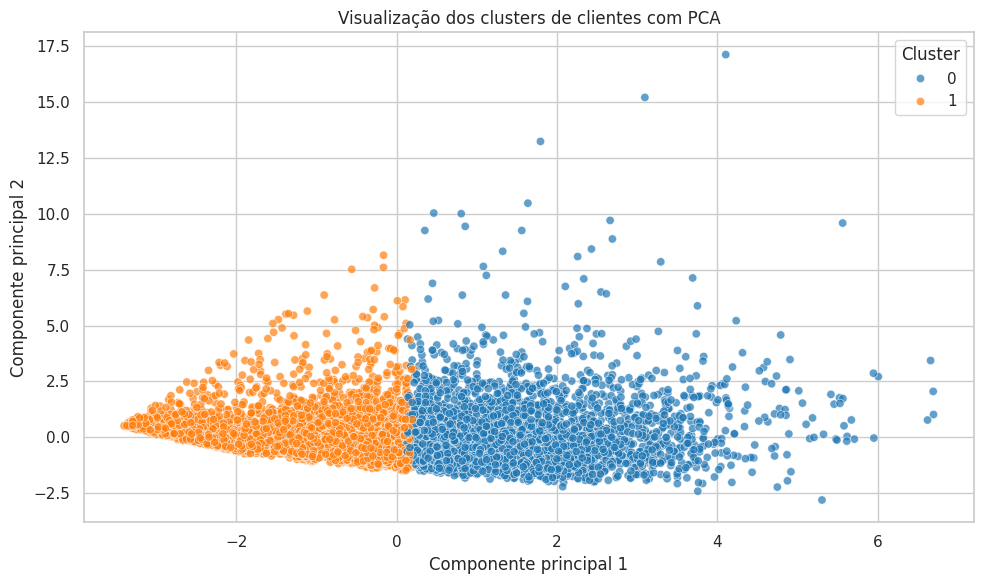

In [17]:
pca = PCA(n_components=2, random_state=42)

componentes = pca.fit_transform(X_scaled)

cliente_agg['pca_1'] = componentes[:, 0]
cliente_agg['pca_2'] = componentes[:, 1]

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=cliente_agg,
    x='pca_1',
    y='pca_2',
    hue='cluster',
    palette='tab10',
    alpha=0.7
)

plt.title('Visualização dos clusters de clientes com PCA')
plt.xlabel('Componente principal 1')
plt.ylabel('Componente principal 2')
plt.legend(title='Cluster')

plt.tight_layout()
plt.show()


Usei o PCA para visualizar os clusters em apenas duas dimensões, já que o modelo foi criado com várias variáveis ao mesmo tempo. Essa redução facilita a visualização dos grupos em um gráfico, sem alterar o resultado do K-Means. No gráfico acima, é possível perceber uma separação entre os clusters 0 e 1, indicando que os clientes foram agrupados em perfis diferentes.

## 14. Nomeação dos segmentos

Depois de analisar os clusters, criei nomes mais fáceis de entender para cada grupo. Essa etapa ajuda a transformar o resultado do modelo em uma interpretação mais próxima do negócio.

In [18]:
perfil_ordenado = perfil_clusters.sort_values(
    'valor_total_medio',
    ascending=False
).reset_index(drop=True)

cluster_maior_valor = perfil_ordenado.loc[0, 'cluster']
cluster_menor_valor = perfil_ordenado.loc[1, 'cluster']

nomes_segmentos = {
    cluster_maior_valor: 'Clientes de maior valor',
    cluster_menor_valor: 'Clientes de menor valor'
}

cliente_agg['segmento'] = cliente_agg['cluster'].map(nomes_segmentos)
perfil_clusters['segmento'] = perfil_clusters['cluster'].map(nomes_segmentos)

display(
    perfil_clusters[
        [
            'cluster',
            'segmento',
            'qtd_clientes',
            'perc_clientes',
            'qtd_pedidos_media',
            'valor_total_medio',
            'ticket_medio_medio',
            'recencia_media'
        ]
    ]
)


,cluster,segmento,qtd_clientes,perc_clientes,qtd_pedidos_media,valor_total_medio,ticket_medio_medio,recencia_media
0,0,Clientes de maior valor,3781,43.54,4.90,2188.98,497.89,227.78
1,1,Clientes de menor valor,4902,56.46,2.34,631.07,287.79,509.72


## 15. Recomendações de negócio

Com base nos segmentos encontrados, pensei em ações para cada grupo de clientes. A ideia é mostrar como a segmentação poderia ser usada em uma estratégia de relacionamento ou marketing.

In [19]:
recomendacoes = pd.DataFrame({
    'segmento': [
        'Clientes de maior valor',
        'Clientes de menor valor'
    ],
    'acao_recomendada': [
        'Criar ações de fidelização, ofertas exclusivas e benefícios para manter esses clientes ativos.',
        'Enviar campanhas de incentivo, cupons e comunicações personalizadas para estimular novas compras.'
    ]
})

display(recomendacoes)


,segmento,acao_recomendada
0,Clientes de maior valor,"Criar ações de fidelização, ofertas exclusivas..."
1,Clientes de menor valor,"Enviar campanhas de incentivo, cupons e comuni..."


## 16. Exportação do resultado

Por fim, exportei a base final com os clusters e segmentos de cada cliente. Esse arquivo pode ser usado depois em análises, dashboards ou apresentações.

In [20]:
arquivo_saida = 'clientes_segmentados_ecommerce.csv'

cliente_agg.to_csv(
    arquivo_saida,
    index=False,
    encoding='utf-8-sig'
)

print('Arquivo gerado:', arquivo_saida)

display(cliente_agg.head())


Arquivo gerado: clientes_segmentados_ecommerce.csv


,customer_id,qtd_pedidos,valor_total,ticket_medio,ultima_compra,qtd_categorias,recencia_dias,cluster,pca_1,pca_2,segmento
0,CUST000001,2,575.87,287.94,2025-06-24,2,556,1,-1.312552,0.069155,Clientes de menor valor
1,CUST000002,6,4353.10,725.52,2025-11-23,5,404,0,3.143970,0.960081,Clientes de maior valor
2,CUST000003,4,637.60,159.40,2026-12-30,4,2,0,0.760736,-1.372296,Clientes de maior valor
3,CUST000004,2,388.31,194.16,2023-12-12,1,1116,1,-2.484777,0.523064,Clientes de menor valor
4,CUST000005,6,2439.93,406.66,2026-09-06,5,117,0,2.543656,-0.625792,Clientes de maior valor


# Conclusão

Neste projeto, foi criada uma segmentação de clientes usando o algoritmo K-Means.

O trabalho passou pelas etapas de carregamento da base, tratamento dos dados, análise exploratória, criação de indicadores por cliente, escolha do número de clusters, treinamento do modelo e interpretação dos resultados.

As hipóteses iniciais foram avaliadas de forma exploratória, comparando os indicadores médios dos clusters. A análise mostrou que o cluster 0 apresentou maior média de pedidos, maior valor total médio, maior ticket médio e menor recência. Isso indica um grupo de clientes mais ativos e com maior valor para o negócio.

Já o cluster 1 apresentou menor valor médio gasto, menor frequência de pedidos e maior tempo desde a última compra, indicando clientes com menor engajamento recente.

Para definir a quantidade de grupos, foram utilizados o Método do Cotovelo e o Silhouette Score. Com base nos resultados, foi escolhido k = 2, mantendo uma segmentação mais fácil de interpretar.

Com a segmentação, cada cliente recebeu um cluster e um nome de segmento, permitindo analisar melhor os perfis de compra. Na prática, esses grupos poderiam apoiar ações de marketing, retenção e relacionamento com clientes.

Como próximos passos, seria possível testar outros algoritmos de clusterização, incluir novas variáveis de comportamento e validar os segmentos com uma análise de negócio mais detalhada.

De forma geral, o projeto mostra como uma técnica simples de Machine Learning pode ajudar a entender melhor o comportamento dos clientes em um cenário de e-commerce.
